In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported!")

✅ Libraries imported!


In [7]:
df = pd.read_csv("../data/processed/sales_data_engineered.csv")
df['Date'] = pd.to_datetime(df['Date'])

print(f"✅ Data Loaded | Shape: {df.shape}")
print(f"Date Range: {df['Date'].min()} → {df['Date'].max()}")

✅ Data Loaded | Shape: (76000, 53)
Date Range: 2022-01-01 00:00:00 → 2024-01-30 00:00:00


In [8]:
# === Remove Leakage & Non-numeric columns ===
leakage_cols = ['Units Sold', 'Demand_to_Inventory_Ratio', 'Stock_Gap', 
                'Promotion_Effectiveness', 'Demand_Rolling_Mean_3']

object_cols = ['Store ID', 'Product ID', 'Category', 'Region', 
               'Weather Condition', 'Seasonality', 'Weather_Promotion', 'Season_Promotion']

drop_cols = ['Date', 'Demand'] + leakage_cols + object_cols

feature_cols = [col for col in df.columns if col not in drop_cols]

X = df[feature_cols]
y = df['Demand']

print(f"✅ Using {len(feature_cols)} numeric features")
print("First 10 features:", feature_cols[:10])

✅ Using 38 numeric features
First 10 features: ['Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic', 'Year', 'Month', 'Week']


In [9]:
train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (60800, 38) | Test: (15200, 38)


In [10]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mae'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("🎯 XGBoost Performance")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"RMSE : {rmse:.2f}")

🎯 XGBoost Performance
MAE  : 2.90
MAPE : 2.90%
RMSE : 6.09


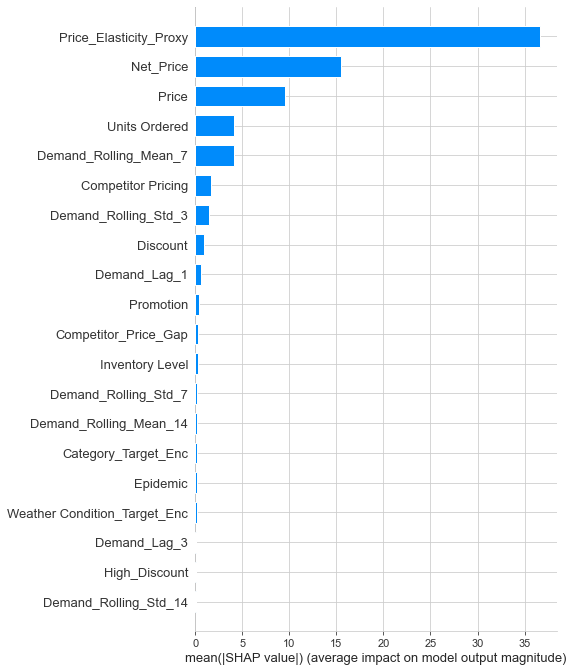

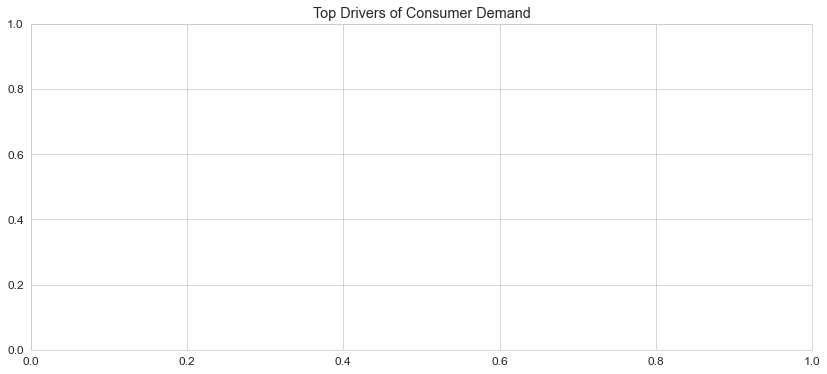

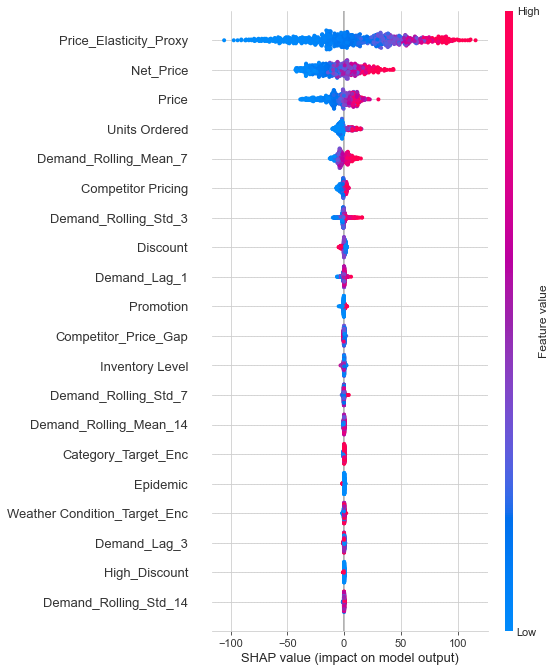

In [11]:
try:
    import shap
    X_sample = X_test.sample(800, random_state=42)
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_sample)

    shap.summary_plot(shap_values, X_sample, plot_type="bar")
    plt.title("Top Drivers of Consumer Demand")
    plt.show()

    shap.summary_plot(shap_values, X_sample)
    plt.show()

except ImportError:
    print("⚠️ SHAP not installed. Run: pip install shap")
except Exception as e:
    print(f"SHAP error: {e}")

In [12]:
Path("../models").mkdir(exist_ok=True)

joblib.dump(xgb_model, "../models/xgb_consumer_demand_model.pkl")

results = pd.DataFrame({
    'Date': df.iloc[train_size:]['Date'].values,
    'Actual': y_test.values,
    'Predicted': y_pred
})
results.to_csv("../data/processed/forecast_results.csv", index=False)

print("✅ Model and results saved!")

✅ Model and results saved!
